# Taller 9 · DFT III: Resolución, leakage y ventanas

**Asignatura:** Teoría de la Información y Procesado de Señal  
**Grado en Ciencia e Ingeniería de Datos (GCED) — Universidad de A Coruña**  
**Duración:** 2 horas  
**Modalidad:** Jupyter Notebook con asistencia de IA

---

## Objetivos de aprendizaje

Al finalizar este taller serás capaz de:

1. Entender la **resolución en frecuencia**: $\Delta f = F_s/N$.
2. Distinguir **zero-padding** (interpolación) de mejora real de resolución.
3. Observar y explicar el fenómeno de **leakage espectral**.
4. Aplicar **ventanas** (rectangular, Hann) y comparar sus efectos.
5. Comprender el **trade-off** entre ancho de lóbulo principal y lóbulos laterales.

---

## Reto central del taller

> **¿Por qué el zero-padding "mejora" visualmente el espectro pero no añade información real sobre las frecuencias?**

## Metodología de trabajo con IA (recordatorio)

- La IA puede escribir el código, pero tú debes **explicar** y **validar**.
- En este taller, lo importante no es "tener una FFT", sino **interpretar** lo que ves.

---

## Identificación del estudiante

Completa los siguientes campos con tu información personal:

- **Apellidos:** Martínez Martínez

- **Nombre:** Jimena

- **Email UDC:** jimena.martinez@udc.es

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 11

print("✓ Entorno listo")

✓ Entorno listo


---

## 1. Resolución en frecuencia

### Contexto teórico

La **resolución en frecuencia** es la separación mínima entre bins de la DFT:

$$\Delta f = \frac{F_s}{N}$$

Para distinguir dos frecuencias cercanas, necesitas $\Delta f$ suficientemente pequeño, lo que requiere **más muestras** (mayor duración $T_d = N/F_s$).

**Relación tiempo-frecuencia:** $\Delta f \cdot T_d = 1$ (principio de incertidumbre).

### Bloque 1 · Dos tonos cercanos: ¿se distinguen?

**Reto conceptual:** Predice si podrás distinguir dos tonos separados 3 Hz.

**Parámetros:**
- Tonos: $f_1 = 50$ Hz, $f_2 = 53$ Hz (separación 3 Hz)
- $F_s = 1000$ Hz
- Dos duraciones: 0.1 s (corta) y 1.0 s (larga)

**Hipótesis previa:**
- Con 0.1 s: $N = $ 100, $\Delta f = $ 10 Hz. ¿Se distinguirán? No se distinguirán.
- Con 1.0 s: $N = $ 1000, $\Delta f = $ 1 Hz. ¿Se distinguirán? Sí se distinguirán.

**Tareas:**
1. Genera las señales corta y larga.
2. Calcula y compara sus espectros.

In [3]:
# === IMPLEMENTACIÓN ===
f1, f2 = 50, 53  # Hz
Fs = 1000        # Hz
dur_short = 0.1  # segundos
dur_long = 1.0   # segundos

# Señal corta
N_short = int(Fs * dur_short)
n_short = np.arange(N_short)
x_short = np.sin(2*np.pi*f1*n_short/Fs) + np.sin(2*np.pi*f2*n_short/Fs)

# Señal larga
N_long = int(Fs * dur_long)
n_long = np.arange(N_long)
x_long = np.sin(2*np.pi*f1*n_long/Fs) + np.sin(2*np.pi*f2*n_long/Fs)

# Calcula espectros one-sided
def espectro_onesided(x, Fs):
    N = len(x)
    Xr = np.fft.rfft(x)
    fr = np.fft.rfftfreq(N, d=1/Fs)
    A = np.abs(Xr) / N
    A[1:-1] *= 2
    return fr, A

fr_short, A_short = espectro_onesided(x_short, Fs)
fr_long, A_long = espectro_onesided(x_long, Fs)

# Resoluciones
Delta_f_short = Fs / N_short
Delta_f_long = Fs / N_long

print(f"Señal corta: N={N_short}, Δf={Delta_f_short} Hz")
print(f"Señal larga: N={N_long}, Δf={Delta_f_long} Hz")
print(f"Separación entre tonos: {f2-f1} Hz")

Señal corta: N=100, Δf=10.0 Hz
Señal larga: N=1000, Δf=1.0 Hz
Separación entre tonos: 3 Hz



✓ Espectros calculados


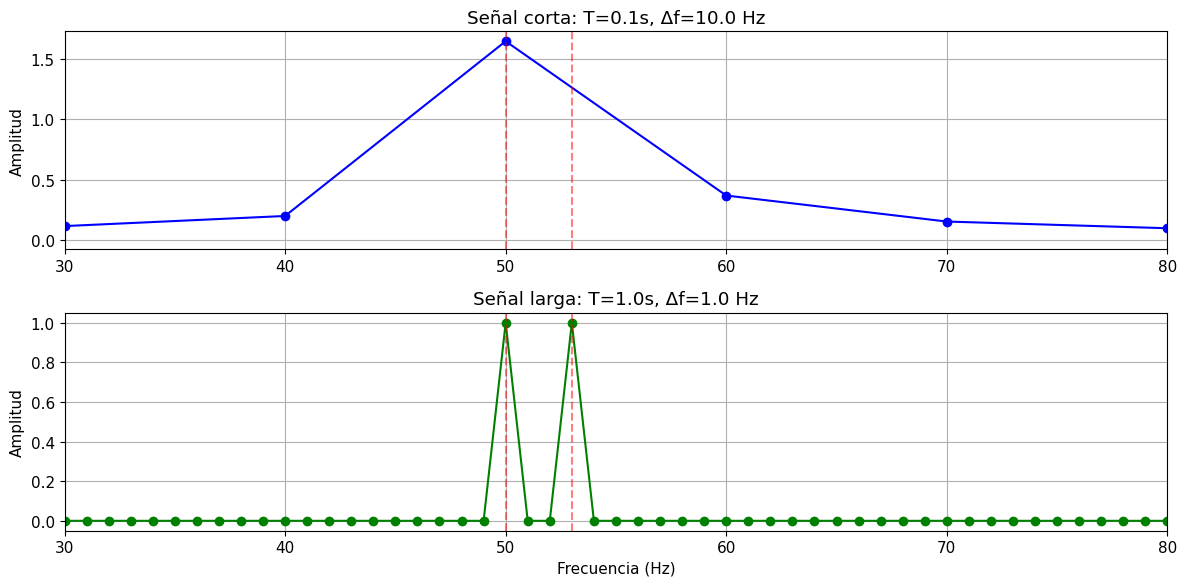

In [4]:
# === VALIDACIÓN ===
assert len(x_short) == int(Fs * dur_short)
assert len(x_long) == int(Fs * dur_long)
print("\n✓ Espectros calculados")

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(fr_short, A_short, 'bo-')
axes[0].set_xlim([30, 80])
axes[0].set_title(f'Señal corta: T={dur_short}s, Δf={Delta_f_short} Hz')
axes[0].axvline(x=f1, color='r', linestyle='--', alpha=0.5)
axes[0].axvline(x=f2, color='r', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Amplitud')

axes[1].plot(fr_long, A_long, 'go-')
axes[1].set_xlim([30, 80])
axes[1].set_title(f'Señal larga: T={dur_long}s, Δf={Delta_f_long} Hz')
axes[1].axvline(x=f1, color='r', linestyle='--', alpha=0.5)
axes[1].axvline(x=f2, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Amplitud')

plt.tight_layout()
plt.show()


### Explicación (OBLIGATORIA)

1. ¿Se distinguen los dos tonos en la señal corta? ¿Por qué sí o no?

   *Tu respuesta:* No, no se distinguen los dos tonos en la señal corta.
   Esto se debe a que la resolución en frecuencia es 10Hz, mientras que la separación entre los tonos es de solo 3 Hz.
   Como la separación es menor que la resolución, ambos tonos caen dentro del mismo bin de la DFT y aparecen como un único pico en el espectro.

2. ¿Por qué aumentar la duración (más muestras) mejora la capacidad de separar frecuencias cercanas?

   *Tu respuesta:* Al aumentar la duración de la señal, aumenta el número de muestras N, lo que reduce la resolució en frecuencia según: Fs/N.
   En este caso, al pasar de 10 Hz a 1 Hz, la resolución es suficiente para distinguir los dos tonos separados 3 Hz.
   Por tanto, una mayor duración permite separar frecuencias más cercanas porque los bins de la DFT están más próximos.

### 🛑 Checkpoint del profesor

- [ ] Dos espectros comparables (misma escala).
- [ ] $\Delta f$ calculado y comentado.
- [ ] Comprensión de por qué la duración afecta la resolución.

---

## 2. Zero-padding: qué hace y qué NO hace

### Contexto teórico

**Zero-padding** consiste en añadir ceros a la señal antes de calcular la FFT (o usar `NFFT > N`).

**Qué hace:**
- Interpola el espectro (más puntos, curva más suave).
- Facilita encontrar el pico exacto.

**Qué NO hace:**
- NO mejora la resolución real (no añade información).
- NO permite distinguir frecuencias que antes no podías.

### Bloque 2 · Zero-padding sobre la señal corta

**Tareas:**
1. Calcula espectros con NFFT = N, 4N y 16N.
2. Superpón los espectros.
3. Razona qué mejora visualmente y qué **no cambia**.

In [5]:
# === IMPLEMENTACIÓN ===
N = len(x_short)
NFFT_1 = N
NFFT_4 = 4 * N
NFFT_16 = 16 * N

def espectro_zeropad(x, Fs, NFFT):
    Xr = np.fft.rfft(x, NFFT)
    fr = np.fft.rfftfreq(NFFT, d=1/Fs)
    A = np.abs(Xr) / len(x)  # Normaliza por N original, no NFFT
    A[1:-1] *= 2    # Normaliza por 2 para tener el espectro de onesided
    return fr, A

fr_1, A_1 = espectro_zeropad(x_short, Fs, NFFT_1)
fr_4, A_4 = espectro_zeropad(x_short, Fs, NFFT_4)
fr_16, A_16 = espectro_zeropad(x_short, Fs, NFFT_16)

# TODO: Calcula el número de ceros que se añade en cada caso, Nceros1, Nceros4, Nceros16
Nceros1 = NFFT_1 - N
Nceros4 = NFFT_4 - N 
Nceros16 = NFFT_16 - N


✓ Zero-padding aplicado
Para NFFT=N=100, se añaden 0 ceros
Para NFFT=4N=400, se añaden 300 ceros
Para NFFT=16N=1600, se añaden 1500 ceros


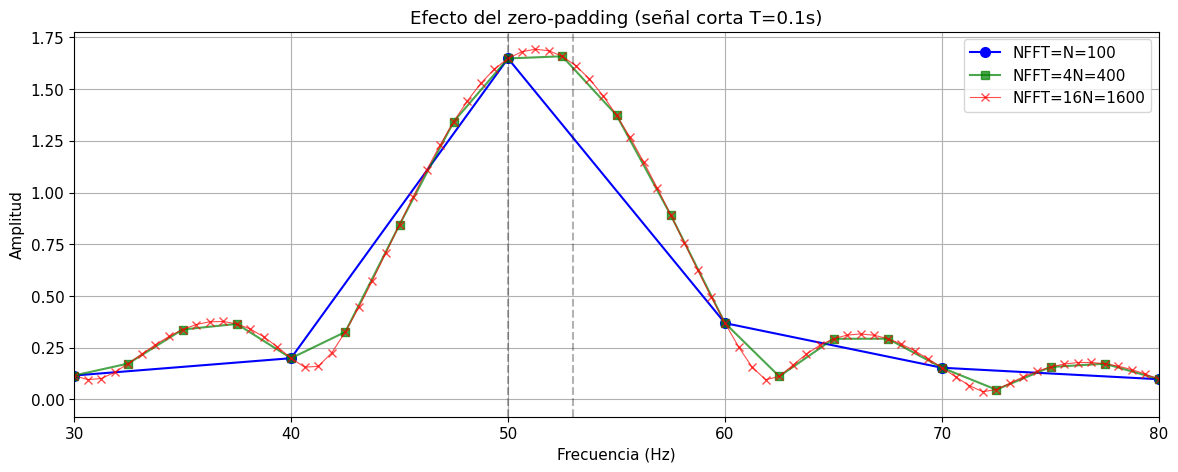

Resolución real: Δf = Fs/N = 10.0 Hz (no cambia con zero-padding)


In [6]:
# === VALIDACIÓN ===
assert Nceros1 == 0
assert Nceros4 == 3*N
assert Nceros16 == 15*N
print("\n✓ Zero-padding aplicado")
print(f"Para NFFT=N={NFFT_1}, se añaden {Nceros1} ceros")
print(f"Para NFFT=4N={NFFT_4}, se añaden {Nceros4} ceros")
print(f"Para NFFT=16N={NFFT_16}, se añaden {Nceros16} ceros")

# Visualización
plt.figure(figsize=(14, 5))

plt.plot(fr_1, A_1, 'bo-', markersize=7, label=f'NFFT=N={NFFT_1}')
plt.plot(fr_4, A_4, 'gs-', markersize=6, alpha=0.7, label=f'NFFT=4N={NFFT_4}')
plt.plot(fr_16, A_16, 'rx-', linewidth=0.8, alpha=0.7, label=f'NFFT=16N={NFFT_16}')

plt.axvline(x=f1, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=f2, color='k', linestyle='--', alpha=0.3)

plt.xlim([30, 80])
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.title('Efecto del zero-padding (señal corta T=0.1s)')
plt.legend()
plt.show()

print(f"Resolución real: Δf = Fs/N = {Fs/N} Hz (no cambia con zero-padding)")

### Explicación (OBLIGATORIA)

**1. Observa las curvas: ¿puedes distinguir mejor los dos tonos con más zero-padding?**

*Tu respuesta:*
```
No, no se pueden distinguir mejor los dos tonos aunque aumente el zero-padding.
Aunque el espectro se ve más suave y con más puntos, sigue apareciendo un único pico porque la resolución real sigue siendo insuficiente ( Deltaf = 10 Hz > 3 Hz).
```

**2. ¿Por qué zero-padding parece "mejorar" el espectro pero no añade información?**

*Tu respuesta:*
```
Porque el zero-padding solo interpola el espectro, añadiendo más puntos entre los ya existentes.
No aumenta la duración de la señal ni el número de muestras reales, por lo que no mejora la resolución en frecuencia ni añade nueva información.
Simplemente hace la gráfica más suave y continua.
```

**3. ¿Cuándo es útil el zero-padding entonces?**

*Tu respuesta:*
```
El zero-padding es útil para:
.Visualizar mejor el espectro
.Localizar con más precisión el pico de frecuencia
.Interpolar valores entre bins
Pero no sirve para separar frecuencias cercanas que no se distinguían antes.
```

## 3: Fenómeno del Leakage

### Contexto teórico

Al analizar una señal mediante la DFT aparecen dos efectos que conviene
distinguir desde el principio, porque tienen la **misma causa** (observar
solo $N$ muestras de la señal) pero **distinta manifestación**:

- **Smearing**: el espectro de la señal observada no es una delta sino una
  función con cierta anchura (típicamente una sinc). Está presente *siempre*
  que tomamos un fragmento finito.
- **Leakage**: cuando la frecuencia de la señal no coincide con un bin de la
  DFT, esa función ensanchada se muestrea fuera de sus ceros y la energía
  aparece repartida en varios bins.

Dicho de otro modo: el smearing es la **causa**, el leakage es el **síntoma
visible** que aparece cuando la frecuencia cae entre bins. En esta sección
nos centramos en el leakage; en la Sección 4 volveremos sobre el smearing
para entender de dónde viene esa anchura.

#### Recordatorio del taller 7

En el taller 7 trabajamos con $N = 16$ muestras y una señal cuya
frecuencia $f_a = 3/8$ caía exactamente en un bin de la DFT. Por eso
obtuvimos un espectro "limpio", con toda la energía en un único bin.

Ahora veremos qué ocurre cuando la frecuencia de la señal **no coincide
con ningún bin**: esa es la condición que hace visible el leakage.

---

Con $\Delta F = F_s / N$, las frecuencias representadas por la DFT son múltiplos de $\Delta F$. Si la frecuencia de la señal no es múltiplo de $\Delta F$:
- La señal no contiene un número entero de periodos en la ventana
- Al asumir periodicidad, aparece una discontinuidad en los extremos
- 👉 La energía se reparte entre varios bins vecinos

Este fenómeno se llama spectral leakage.

### Bloque 3a · Efecto en el espectro: energía repartida entre bins

Ahora trabajaremos con una señal más larga ($N = 100$ muestras, $F_s = 1000$ Hz) para analizar el fenómeno del **leakage**.

#### 📝 Hipótesis previa

**Preguntas:**

- Con $F_s = 1000$ Hz y $N = 100$, ¿cuál es $\Delta F$? 10 Hz
- ¿$F_{2a} = 50$ Hz es múltiplo de $\Delta F$? Sí
- ¿$F_{2b} = 53$ Hz es múltiplo de $\Delta F$? No
- ¿En cuál de las dos señales esperas que la energía esté concentrada en un único bin? En la de 50 Hz.
- ¿En cuál esperas que la energía se reparta entre varios bins? En 53 Hz.

In [7]:
# === PARÁMETROS PARA PARTES 3a Y 3b ===
Fs3 = 1000      # Hz
N3 = 100        # muestras
n3 = np.arange(N3)  # vector de índices de muestras

A3 = 1.0
F3a = 50        # Hz - frecuencia alineada con un bin (coherent sampling)
F3b = 53        # Hz - frecuencia no alineada con los bins

# TODO: Calcula la separación entre bins, DeltaF3 para el intervalo [0, Fs3)
DeltaF3 = Fs3 / N3

# TODO: Calcula los bins teóricos para F3a y F3b, k3a y k3b
k3a = F3a / DeltaF3
k3b = F3b / DeltaF3

In [8]:
assert k3a.is_integer()
assert not k3b.is_integer()
assert k3a == np.floor(k3b)

print(f"Fs = {Fs3} Hz, N3 = {N3}")
print(f"Resolución frecuencial: ΔF3 = {DeltaF3} Hz")
print(f"Duración: Td = {N3/Fs3} s")
print("\nNOTA importante:")
print("La DFT solo evalúa frecuencias separadas ΔF.")
print(f"En este caso: ΔF = {DeltaF3} Hz → solo puede representar 0, {DeltaF3}, {2*DeltaF3}, {3*DeltaF3}, {4*DeltaF3}, ... Hz")
print(f"Por tanto, no puede colocar un pico exactamente en {F3b} Hz.")
print("La energía tendrá que repartirse entre bins cercanos.")

print(f"\nF3a = {F3a} Hz")
print(f"Bin correspondiente: k = {k3a}")
print(f"¿Cae en bin exacto? {k3a.is_integer()}")

print(f"\nF3b = {F3b} Hz")
print(f"Bin correspondiente: k = {k3b}")
print(f"¿Cae en bin exacto? {k3b.is_integer()}")
print("\nPregunta:")
print(f"Si {F3b} Hz no coincide con ningún bin, ¿dónde esperas que aparezca su energía en el espectro?")

Fs = 1000 Hz, N3 = 100
Resolución frecuencial: ΔF3 = 10.0 Hz
Duración: Td = 0.1 s

NOTA importante:
La DFT solo evalúa frecuencias separadas ΔF.
En este caso: ΔF = 10.0 Hz → solo puede representar 0, 10.0, 20.0, 30.0, 40.0, ... Hz
Por tanto, no puede colocar un pico exactamente en 53 Hz.
La energía tendrá que repartirse entre bins cercanos.

F3a = 50 Hz
Bin correspondiente: k = 5.0
¿Cae en bin exacto? True

F3b = 53 Hz
Bin correspondiente: k = 5.3
¿Cae en bin exacto? False

Pregunta:
Si 53 Hz no coincide con ningún bin, ¿dónde esperas que aparezca su energía en el espectro?


In [9]:
# === IMPLEMENTACIÓN ===

# TODO: Genera la señal sinusoidal x3a con amplitud A3, frecuencia F3a,
# frecuencia de muestreo Fs3 y vector de índices de muestras n3
x3a = A3 * np.sin(2 * np.pi * F3a * n3 / Fs3)

# TODO: Genera la señal sinusoidal x3b con amplitud A3, frecuencia F3b,
# frecuencia de muestreo Fs3 y vector de índices de muestras n3
x3b = A3 * np.sin(2 * np.pi * F3b * n3 / Fs3)

# TODO: Calcula el espectro de amplitud one-sided de x3a y x3b usando np.fft.fft(), Afrec_3a_onesided y Afrec_3b_onesided
X3a = np.fft.rfft(x3a)
X3b = np.fft.rfft(x3b)

Afrec_3a_onesided = np.abs(X3a) / N3 
Afrec_3b_onesided = np.abs(X3b) / N3 

Afrec_3a_onesided[1:-1] *= 2
Afrec_3b_onesided[1:-1] *= 2

In [10]:
# Validación
fr = np.fft.rfftfreq(N3, d=1/Fs3)
idx_f3a = np.argmin(np.abs(fr - F3a))
idx_f3b = np.argmin(np.abs(fr - F3b))

assert np.isclose(Afrec_3a_onesided[idx_f3a], A3), \
    "No has calculado correctamente el espectro one-sided de x3a"
assert Afrec_3b_onesided[idx_f3b] < A3, \
    "No has calculado correctamente el espectro one-sided de x3b"

# Amplitudes estimadas
print(f"\nAmplitud estimada en F3a = {F3a} Hz")
print(f"Bin teórico: k = {F3a / DeltaF3}")
print(f"Bin usado: {idx_f3a}")
print(f"Valor estimado: {Afrec_3a_onesided[idx_f3a]:.4f} (real: {A3})")
print("La amplitud estimada coincide con la real porque la frecuencia cae exactamente en un bin.\n")

print(f"Amplitud estimada en F3b = {F3b} Hz")
print(f"Bin teórico: k = {F3b / DeltaF3}")
print(f"Bin más cercano usado: {idx_f3b}")
print(f"Valor estimado: {Afrec_3b_onesided[idx_f3b]:.4f} (real: {A3})")
print("La amplitud estimada es menor que la real porque la frecuencia no cae exactamente en un bin y su energía se reparte entre varios bins (leakage).")


Amplitud estimada en F3a = 50 Hz
Bin teórico: k = 5.0
Bin usado: 5
Valor estimado: 1.0000 (real: 1.0)
La amplitud estimada coincide con la real porque la frecuencia cae exactamente en un bin.

Amplitud estimada en F3b = 53 Hz
Bin teórico: k = 5.3
Bin más cercano usado: 5
Valor estimado: 0.8583 (real: 1.0)
La amplitud estimada es menor que la real porque la frecuencia no cae exactamente en un bin y su energía se reparte entre varios bins (leakage).


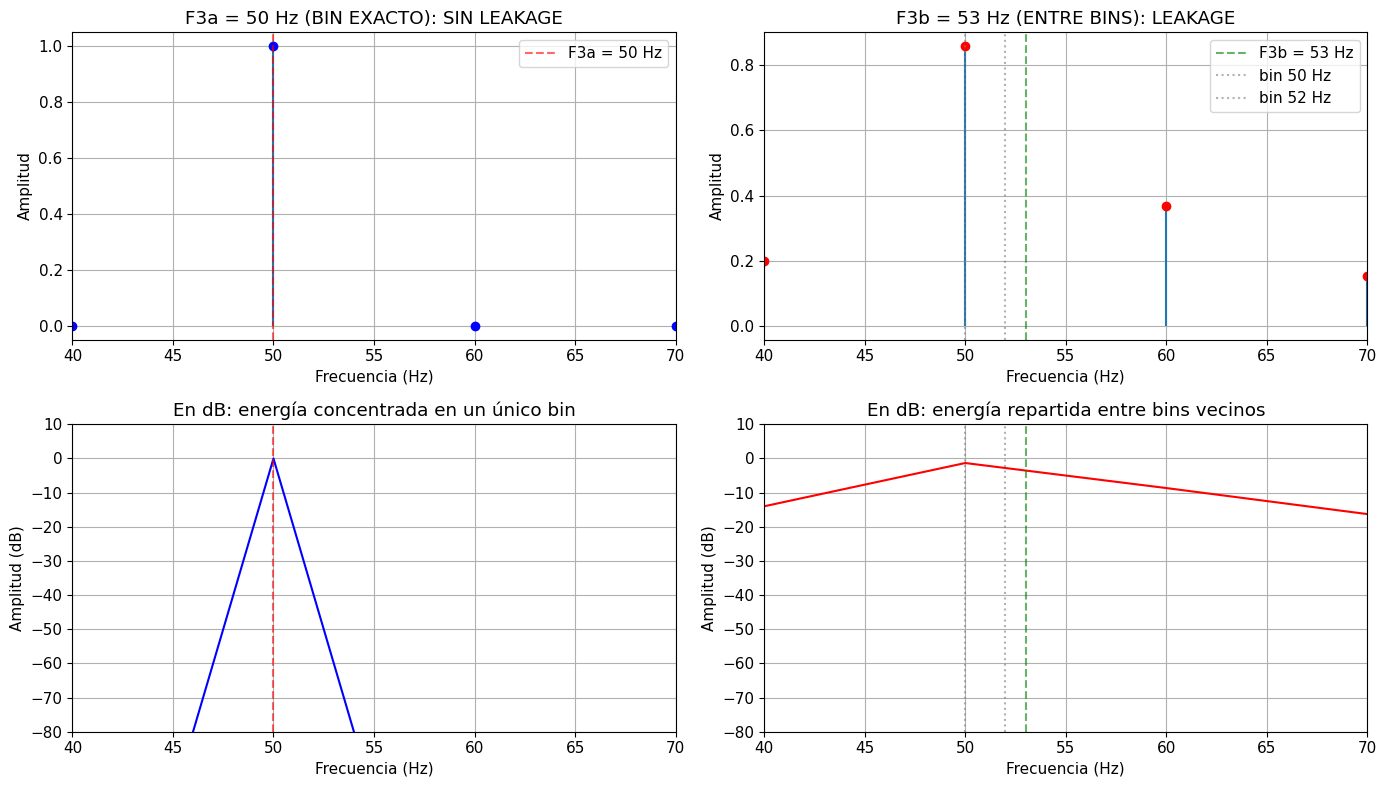

In [11]:
# === VISUALIZACIÓN COMPARATIVA ===
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Frecuencia alineada con un bin
axes[0, 0].stem(fr, Afrec_3a_onesided, basefmt=' ', markerfmt='bo')
axes[0, 0].set_xlim([40, 70])
axes[0, 0].axvline(x=F3a, color='r', linestyle='--', alpha=0.6, label=f'F3a = {F3a} Hz')
axes[0, 0].set_title(f'F3a = {F3a} Hz (BIN EXACTO): SIN LEAKAGE')
axes[0, 0].set_xlabel('Frecuencia (Hz)')
axes[0, 0].set_ylabel('Amplitud')
axes[0, 0].legend()

# Frecuencia no alineada con bins
axes[0, 1].stem(fr, Afrec_3b_onesided, basefmt=' ', markerfmt='ro')
axes[0, 1].set_xlim([40, 70])
axes[0, 1].axvline(x=F3b, color='g', linestyle='--', alpha=0.6, label=f'F3b = {F3b} Hz')
axes[0, 1].axvline(x=50, color='gray', linestyle=':', alpha=0.6, label='bin 50 Hz')
axes[0, 1].axvline(x=52, color='gray', linestyle=':', alpha=0.6, label='bin 52 Hz')
axes[0, 1].set_title(f'F3b = {F3b} Hz (ENTRE BINS): LEAKAGE')
axes[0, 1].set_xlabel('Frecuencia (Hz)')
axes[0, 1].set_ylabel('Amplitud')
axes[0, 1].legend()

# En dB - frecuencia alineada
A_dB_1 = 20 * np.log10(Afrec_3a_onesided + 1e-10)
axes[1, 0].plot(fr, A_dB_1, 'b-')
axes[1, 0].set_xlim([40, 70])
axes[1, 0].set_ylim([-80, 10])
axes[1, 0].axvline(x=F3a, color='r', linestyle='--', alpha=0.6)
axes[1, 0].set_title('En dB: energía concentrada en un único bin')
axes[1, 0].set_xlabel('Frecuencia (Hz)')
axes[1, 0].set_ylabel('Amplitud (dB)')

# En dB - frecuencia entre bins (leakage)
A_dB_2 = 20 * np.log10(Afrec_3b_onesided + 1e-10)
axes[1, 1].plot(fr, A_dB_2, 'r-')
axes[1, 1].set_xlim([40, 70])
axes[1, 1].set_ylim([-80, 10])
axes[1, 1].axvline(x=F3b, color='g', linestyle='--', alpha=0.6)
axes[1, 1].axvline(x=50, color='gray', linestyle=':', alpha=0.6)
axes[1, 1].axvline(x=52, color='gray', linestyle=':', alpha=0.6)
axes[1, 1].set_title('En dB: energía repartida entre bins vecinos')
axes[1, 1].set_xlabel('Frecuencia (Hz)')
axes[1, 1].set_ylabel('Amplitud (dB)')

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. Describe visualmente la diferencia entre el espectro de 50 Hz y el de 53 Hz.**
(Fíjate en cómo se distribuye la energía en los bins en cada caso.)


*Tu respuesta:*

```
En el caso de 50 Hz, la energía aparece concentrada en un único bin, generando un pico alto y limpio en esa frecuencia.
En el caso de 53 Hz, la energía está repartida entre varios bins cercanos, por lo que aparecen varios picos más pequeós en lugar de uno solo.
Esto hace que el espectro de 53 Hz se vea más ancho o disperso.
```

**2. ¿Por qué la amplitud estimada para 53 Hz es menor que la real?**
(Pista: la DFT solo puede representar frecuencias separadas ΔF. ¿Qué ocurre si la frecuencia de la señal no coincide exactamente con un bin?)

*Tu respuesta:*

```
Porque la DFT solo puede representar frecuencias separadas por DeltaF.
Como 53 Hz no coincide exactamente con ningún bin, su energía no puede concentrarse en uno solo y se reparte entre varios bins.
Al dividirse la energía, el valor en cada bin es menor que la amplitud real.
```

**3. ¿Cómo podrías reducir el leakage? (Pista: piensa en $\Delta F$)**

*Tu respuesta:*

```
Se puede reducir el leakage de varias formas:
. Aumentando N -> disminuyendo DeltaF y mejora la resolución en frecuencia.
. Haciendo que la señal cumpla coherent sampling (frecuencia alineada con un bin).
. Aplicando ventanas para suavizar discontinuidades.
```

### Bloque 3b · Periodicidad implícita y discontinuidad

La DFT asume que el bloque de $N$ muestras que analizamos se repite
periódicamente. Si la señal contiene un número entero de periodos dentro
de la ventana, los extremos "encajan" y la periodización es continua.
Si no, aparece una **discontinuidad** en cada frontera entre repeticiones.

Esta discontinuidad es la **vista temporal** del mismo fenómeno que ya
hemos observado en frecuencia: una señal periódica con saltos contiene
energía en muchas frecuencias armónicas, y eso es exactamente lo que la
DFT nos muestra como "energía repartida entre bins". No es una causa
nueva del leakage, es la *misma cosa* mirada desde el dominio del tiempo.

Si la señal original es periódica, al seleccionar \(N\) muestras estamos en realidad **enventanando** la señal.

Si la señal enventanada contiene un número entero de periodos dentro de esas \(N\) muestras, los extremos encajan perfectamente; pero si no:

- La señal no termina en el mismo valor y fase con que empieza  
- Al repetirla, aparece una discontinuidad artificial en los bordes  

Esa discontinuidad no corresponde a una sola frecuencia pura, sino que introduce múltiples componentes en frecuencia. Como consecuencia, la energía de una frecuencia “ideal” se reparte entre varios bins → esto es el **leakage** (fuga espectral).

El **coherent sampling** ocurre cuando la señal contiene un número entero de periodos dentro de la ventana, lo que evita la discontinuidad y, por tanto, elimina el leakage en la DFT.


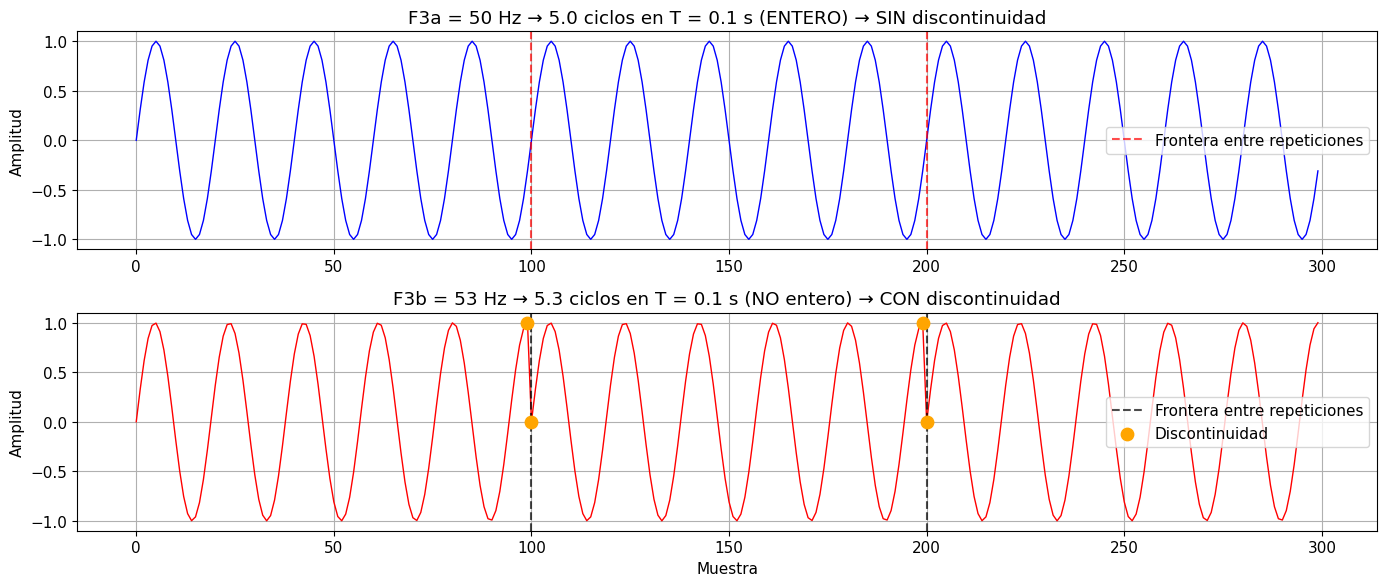

Duración de la ventana: T = 0.1 s
ΔF = 10.0 Hz

F3a = 50 Hz -> 5.0 ciclos completos en la ventana ✓
F3b = 53 Hz -> 5.300000000000001 ciclos en la ventana ✗

Para F3b = 53 Hz:
Valor al inicio x[0] = 0.0000
Valor al final  x[N3-1] = 0.9998
Salto entre repeticiones = 0.9998


In [12]:
# === VISUALIZACIÓN TEMPORAL: por qué aparece el leakage ===
T3 = N3 / Fs3   # duración de la ventana

# Repetimos cada señal 3 veces para visualizar la periodicidad asumida por la DFT
x3a_rep = np.tile(x3a, 3)
x3b_rep = np.tile(x3b, 3)
n3_rep = np.arange(len(x3a_rep))

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Caso alineado: 50 Hz
axes[0].plot(n3_rep, x3a_rep, 'b-', linewidth=1)
axes[0].axvline(x=N3, color='r', linestyle='--', alpha=0.7, label='Frontera entre repeticiones')
axes[0].axvline(x=2*N3, color='r', linestyle='--', alpha=0.7)
axes[0].set_title(f'F3a = {F3a} Hz → {F3a*T3:.1f} ciclos en T = {T3:.1f} s (ENTERO) → SIN discontinuidad')
axes[0].set_ylabel('Amplitud')
axes[0].legend()

# Caso no alineado: 53 Hz
axes[1].plot(n3_rep, x3b_rep, 'r-', linewidth=1)
axes[1].axvline(x=N3, color='k', linestyle='--', alpha=0.7, label='Frontera entre repeticiones')
axes[1].axvline(x=2*N3, color='k', linestyle='--', alpha=0.7)

# Marcamos las dos discontinuidades: entre 1ª-2ª y entre 2ª-3ª repetición
axes[1].scatter(
    [N3-1, N3, 2*N3-1, 2*N3],
    [x3b[-1], x3b[0], x3b[-1], x3b[0]],
    c='orange', s=80, zorder=5, label='Discontinuidad'
)

axes[1].set_title(f'F3b = {F3b} Hz → {F3b*T3:.1f} ciclos en T = {T3:.1f} s (NO entero) → CON discontinuidad')
axes[1].set_xlabel('Muestra')
axes[1].set_ylabel('Amplitud')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Duración de la ventana: T = {T3} s")
print(f"ΔF = {DeltaF3} Hz\n")

print(f"F3a = {F3a} Hz -> {F3a*T3} ciclos completos en la ventana ✓")
print(f"F3b = {F3b} Hz -> {F3b*T3} ciclos en la ventana ✗")

print(f"\nPara F3b = {F3b} Hz:")
print(f"Valor al inicio x[0] = {x3b[0]:.4f}")
print(f"Valor al final  x[N3-1] = {x3b[-1]:.4f}")
print(f"Salto entre repeticiones = {abs(x3b[0] - x3b[-1]):.4f}")

### ✍️ Explicación (OBLIGATORIA)

**1. Observa las dos señales repetidas periódicamente. ¿Qué diferencia aparece en los puntos donde se unen los fragmentos?**
(Fíjate en el valor y la fase al final y al inicio de cada repetición.)


*Tu respuesta:*

```
En la señal de 50 Hz, el final y el inicio coinciden en valor y fase, por lo que al repetirse la señal no hay saltos y la unión es continua.
En la señal de 53 Hz, el valor final es muy distinto del valor inicial, por lo que al repetirse aparece un salto brusco.
```

**2. En el caso de 53 Hz, ¿por qué aparece una discontinuidad al repetir la señal?**
(Pista: piensa en cuántos ciclos contiene la señal dentro de la ventana de duración \(T\).)

*Tu respuesta:*

```
Porque la señal no contiene un número entero de ciclos en la ventana:
. 50 Hz -> 5 ciclos exactos
. 53 Hz -> 5.3 ciclos
Al no terminar en el mismo punto en el que empieza, la señal se corta y al repetirse genera un salto.
```

**3. Si una discontinuidad introduce cambios bruscos en la señal, ¿qué implica eso en términos de contenido en frecuencia?**
(Pista: ¿los cambios rápidos corresponden a pocas o a muchas frecuencias?)

*Tu respuesta:*

```
Una discontinuidad implica cambios bruscos en la señal. Los cambios bruscos contienen muchas frecuencias. Por eso la energía se reparte entre muchos bins -> leakage.
```

**4. En resumen, ¿Qué condición debería haber tenido $\Delta F$ para no tener problema con una señal con frecuencia $F_0$**

*Tu respuesta:*

```
La señal debería cumplir:
Tener un número entero de ciclos en la ventana, equivalente a: F = k * DeltaF.
La frecuencia está alineada con un bin.
```

---

### Bloque 3c · Efecto de \(N\) en la resolución frecuencial y en el leakage

Vamos a comprobar experimentalmente cómo afecta $N$ al spectral leakage, usando $F_{3b} = 53$ Hz.

In [13]:
# === IMPLEMENTACIÓN ===
# TODO: Genera un vector de valores de N, valores_N, que correponden a unos DeltaF iguales a 10, 4, 2 y 1 Hz
valores_N = [100, 250, 500, 1000]

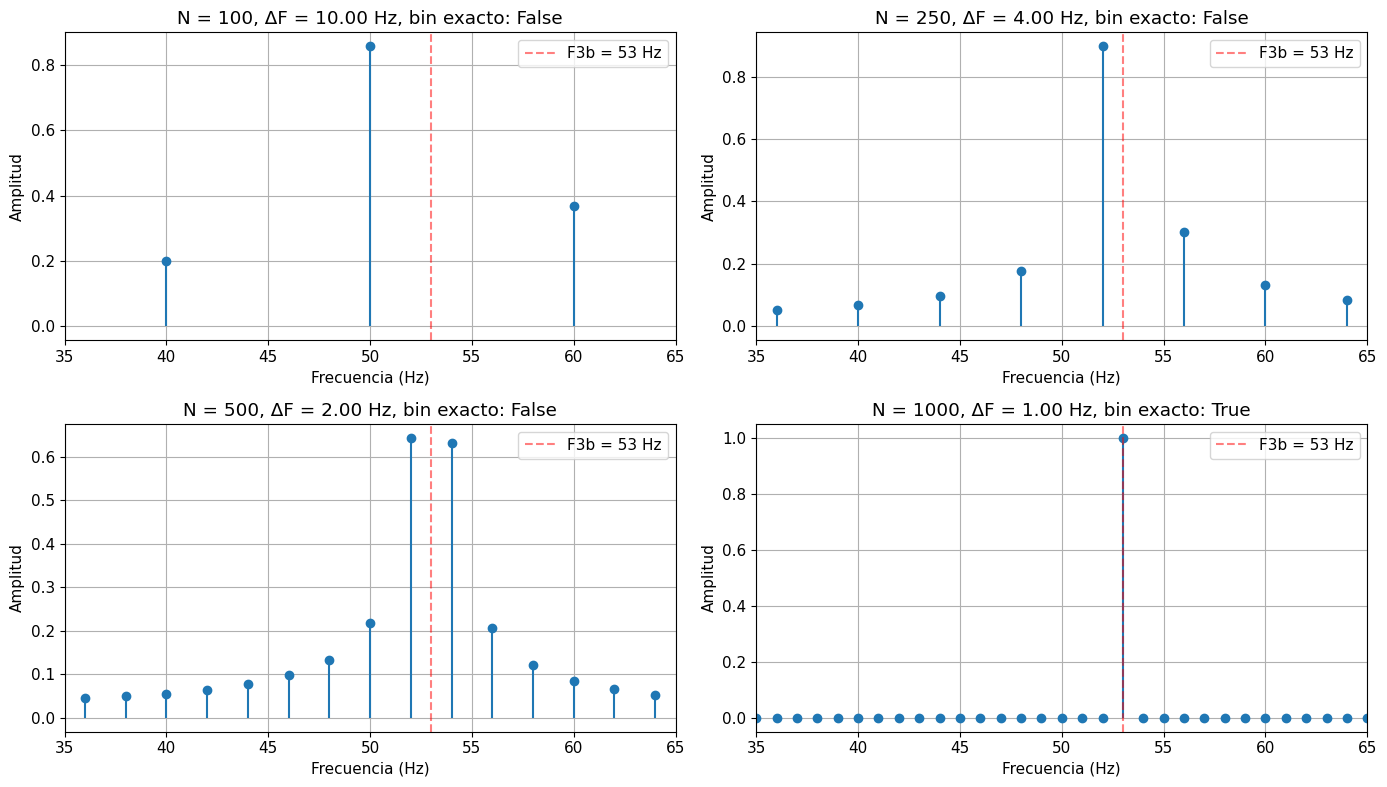

In [14]:
# === VALIDACIÓN ===
assert(valores_N==[100, 250, 500, 1000])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, N_i in enumerate(valores_N):
    n_i = np.arange(N_i)
    x_i = np.sin(2 * np.pi * F3b * n_i / Fs3)

    Xr_i = np.fft.rfft(x_i)
    fr_i = np.fft.rfftfreq(N_i, d=1/Fs3)

    A_i = np.abs(Xr_i) / N_i
    A_i[1:-1] *= 2

    Delta_f_i = Fs3 / N_i
    k_i = F3b / Delta_f_i
    es_exacto = np.isclose(k_i, round(k_i))

    axes[i].stem(fr_i, A_i, basefmt=' ')
    axes[i].set_xlim([35, 65])
    axes[i].axvline(x=F3b, color='r', linestyle='--', alpha=0.5, label=f'F3b = {F3b} Hz')
    axes[i].set_title(f'N = {N_i}, ΔF = {Delta_f_i:.2f} Hz, bin exacto: {es_exacto}')
    axes[i].set_xlabel('Frecuencia (Hz)')
    axes[i].set_ylabel('Amplitud')
    axes[i].legend()

plt.tight_layout()
plt.show()

### ✍️ Explicación (OBLIGATORIA)

**1. ¿Qué ocurre con la distribución de la energía en el espectro cuando aumenta \(N\)?**
(Fíjate en cómo se reparte la energía entre los bins)

```
Cuando aumentas N, la energía del seno se va concentrando progresivamente en menos bins.
. Con N = 100: la energía está repartida entre varios bins (50 Hz, 60 Hz...)
. Con N = 250: sigue habiendo dispersión, pero ya hay un pico más claro en torno a 53 Hz.
. Con N = 500: la energía se concentra mucho más alrededor del pico principal, aunque aún hay cola en bins cercanos.
. Con N = 1000: prácticamente toda la energía está en un único bin (53 Hz).
```

**2. ¿Con qué valor de \(N\) el pico es más concentrado? ¿Por qué?**
(Pista: piensa en la separación entre bins, \(\Delta F\).)

*Tu respuesta:*

```
N = 1000
Aquí DeltaF = 1 Hz, el bin de 53 Hz existe exactamente en la rejilla de la DFT. Eso significa que la frecuencia de la señal coincide exactamente con un bin.
Cuando esto ocurre no hay fuga espectral y toda la energía cae en un único bin.
```

**3. ¿Por qué aumentar \(N\) reduce el leakage visible?**
(Pista: ¿qué ocurre con la rejilla de frecuencias de la DFT?)

*Tu respuesta:*

```
Porque al aumentar N: DeltaF baja, la rejilla de frecuencias se vuelve más fina y es más probable que la frecuencia de la señal caiga cerca o exactamente sobre un bin.
```

### Bloque 3d · Espectros y verificación de Parseval

**Concepto clave:** Cuando aparece leakage, la energía de la señal ya no queda concentrada en un único bin, sino que se reparte entre varios. Sin embargo, la **energía total se conserva**: el leakage no crea ni destruye energía, solo la redistribuye. Esto es una consecuencia del **teorema de Parseval**

$$\sum |x[n]|^2 = \frac{1}{N} \sum |X[k]|^2$$

En este bloque compararemos dos casos:

- **Señal alineada con la rejilla de la DFT** → la energía se concentra en un único pico
- **Señal no alineada** → la energía se reparte entre varios bins (leakage)

In [15]:
# === IMPLEMENTACIÓN: Espectros y Parseval ===

# Función para calcular el espectro de amplitud onesided de una señal
def espectro_onesided(x, Fs):
    N = len(x)

    # TODO:Calcular la DFT de la señal, X
    X = np.fft.fft(x)

    # TODO: Calcular el espectro de amplitud onesided de la señal, A
    A = np.abs(X) / N 

    # TODO: Calcular el vector de frecuencias normalizadas del espectro de amplitud onesided, fr
    fr = np.fft.fftfreq(N, d=1/Fs)

    return fr, A, X

# Espectros (usamos los mismos x3a y x3bdel bloque anterior)
fr_on, A_on, X_on = espectro_onesided(x3a, Fs3)
fr_off, A_off, X_off = espectro_onesided(x3b, Fs3)

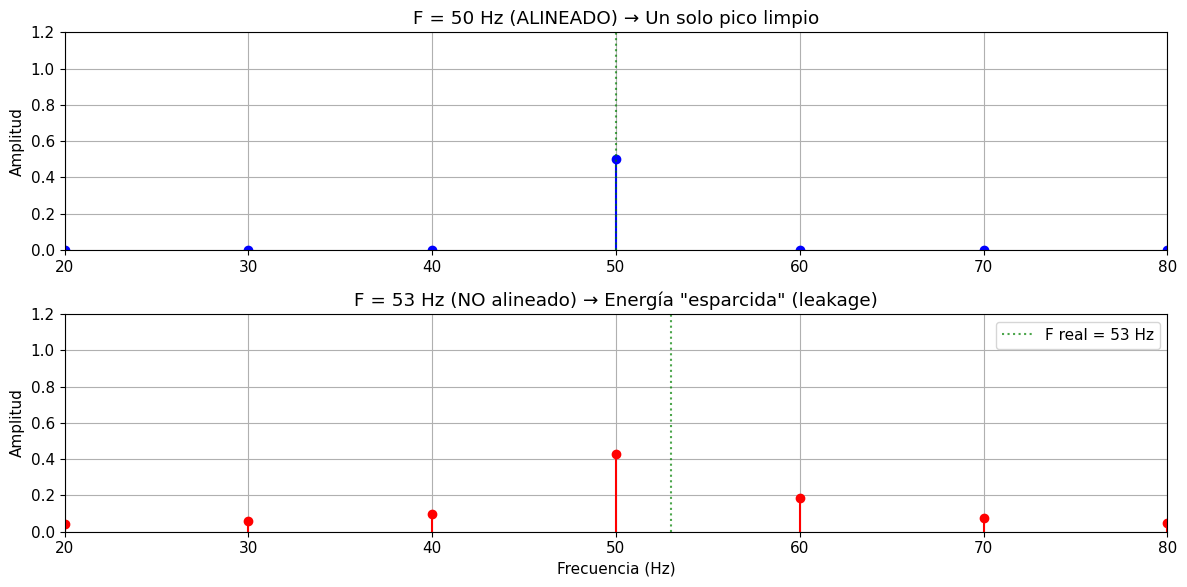

In [16]:
# Visualización de espectros
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].stem(fr_on, A_on, basefmt=' ', markerfmt='bo', linefmt='b-')
axes[0].set_xlim([20, 80])
axes[0].set_ylim([0, 1.2])
axes[0].axvline(x=F3a, color='g', linestyle=':', alpha=0.7)
axes[0].set_title(f'F = {F3a} Hz (ALINEADO) → Un solo pico limpio')
axes[0].set_ylabel('Amplitud')

axes[1].stem(fr_off, A_off, basefmt=' ', markerfmt='ro', linefmt='r-')
axes[1].set_xlim([20, 80])
axes[1].set_ylim([0, 1.2])
axes[1].axvline(x=F3b, color='g', linestyle=':', alpha=0.7, label=f'F real = {F3b} Hz')
axes[1].set_title(f'F = {F3b} Hz (NO alineado) → Energía "esparcida" (leakage)')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Amplitud')
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
# === VERIFICACIÓN DE PARSEVAL ===
# Parseval: sum(|x[n]|²) = (1/N) * sum(|X[k]|²)
# Calculamos la energía en tiempo y frecuencia

energia_tiempo_on = np.sum(x3a**2)
energia_tiempo_off = np.sum(x3b**2)

# Para verificar Parseval con rfft, necesitamos considerar la simetría
energia_freq_on = np.sum(np.abs(X_on)**2) / len(X_on)
energia_freq_off = np.sum(np.abs(X_off)**2) / len(X_off)

# Validación
assert np.isclose(energia_tiempo_on, energia_freq_on, rtol=1e-10)
assert np.isclose(energia_tiempo_off, energia_freq_off, rtol=1e-10)
assert np.isclose(energia_tiempo_on, energia_tiempo_off, rtol=0.01)
print("\n✓ Parseval verificado")

print("=== VERIFICACIÓN DE PARSEVAL ===")
print(f"\nCaso ALINEADO:")
print(f"  Energía en tiempo: {energia_tiempo_on:.4f}")
print(f"  Energía en frecuencia: {energia_freq_on:.4f}")

print(f"\nCaso NO ALINEADO:")
print(f"  Energía en tiempo: {energia_tiempo_off:.4f}")
print(f"  Energía en frecuencia: {energia_freq_off:.4f}")

print(f"\n→ La energía es la MISMA en ambos casos ({energia_tiempo_on:.4f} ≈ {energia_tiempo_off:.4f})")
print("→ El leakage NO crea ni destruye energía, solo la redistribuye")



✓ Parseval verificado
=== VERIFICACIÓN DE PARSEVAL ===

Caso ALINEADO:
  Energía en tiempo: 50.0000
  Energía en frecuencia: 50.0000

Caso NO ALINEADO:
  Energía en tiempo: 49.9726
  Energía en frecuencia: 49.9726

→ La energía es la MISMA en ambos casos (50.0000 ≈ 49.9726)
→ El leakage NO crea ni destruye energía, solo la redistribuye


### ✍️ Explicación (OBLIGATORIA)

**1. Describe la diferencia visual entre ambos espectros.**  
(¿Dónde está concentrada la energía en el caso alineado? ¿Cómo se distribuye en el caso no alineado?)

*Tu respuesta:*

```
En el caso alineado (50 Hz), la energía está conectada en un único bin, apareciendo un pico alto y bien definido en esa frecuencia.
En el caso no alineado (53 Hz), la energía se distribuye entre varios bins cercanos, dando lugar a un espectro más ancho con múltiples picos de menor amplitud.
Esto es consecuencia del leakage, que reparte la energía cuando la frecuencia no coincide con un bin.
```

**2. ¿Por qué la energía es la misma en ambos casos aunque el espectro se vea diferente?**

*Tu respuesta:*

```
La energía es la misma en ambos casos debido al teorema de Parseval, que establece que la energía total de la señal se conserva entre el dominio del tiempo y el dominio de la frecuencia.
El leakage no crea ni destruye energía, solo la redistribuye entre diferentes bins del espectro. Por eso, aunque el espectro tenga formas distintas, la energía total sigue siendo la misma.
```

## 4: El Fenómeno del Smearing

#### 🔍 Volviendo sobre la causa común

En la Sección 3 vimos el leakage como "energía repartida entre bins" cuando
la frecuencia no está alineada. Pero esa explicación deja una pregunta
abierta: **¿por qué la energía se reparte?** La respuesta es que el espectro
de la señal observada **nunca** es un pico infinitamente estrecho —ni
siquiera cuando la frecuencia está perfectamente alineada con un bin—.
Esa anchura intrínseca es lo que llamamos **smearing**.

¿Por qué entonces no la vimos en el caso alineado del Bloque 3a, donde el
pico parecía perfectamente limpio? Porque la DFT solo nos enseña $N/2 + 1$
muestras del espectro continuo, y resulta que cuando la frecuencia está
alineada, esas muestras caen **exactamente sobre los ceros** de la función
ensanchada. El smearing está ahí, pero no se ve.

---


#### Intuición

Cuando analizamos una señal con la DFT, no observamos la señal completa,
sino solo un fragmento de duración finita $T = N/F_s$. Esto equivale a
**multiplicar la señal por una ventana rectangular** en el tiempo, y por
la propiedad de convolución, equivale a **convolucionar el espectro
verdadero por el espectro de la ventana** en frecuencia.

$$x_{\text{obs}}[n] = x[n] \cdot w[n]$$

donde:

- $w[n] = 1$ para $0 \le n < N$  
- $w[n] = 0$ en otro caso  

---

#### Consecuencia fundamental

Multiplicar en el tiempo tiene un efecto directo en frecuencia:

> La multiplicación en tiempo equivale a una **convolución en frecuencia**

---

#### ¿Qué implica esto?

Si la señal original es una senoide pura:

- Su espectro ideal es un **impulso (delta)** en la frecuencia $\omega_0$

Pero al observar solo un fragmento:

- ese impulso se **convierte en una función ensanchada**

👉 La energía ya no está concentrada en un punto, sino distribuida alrededor de la frecuencia real.

---

#### Resultado: Smearing

Este ensanchamiento del espectro se llama **smearing**.

- La energía se mantiene centrada en la frecuencia correcta  
- Pero se reparte en un intervalo de frecuencias  

---

#### 🔬 Interpretación física

> Para definir una frecuencia perfectamente necesitas tiempo infinito.  
> Si solo observas un fragmento, aparece incertidumbre en frecuencia.

---

#### 📐 Relación matemática

La transformada de la ventana rectangular es una función tipo sinc:

$$W(\omega) \propto \text{sinc}(\omega T/2)$$

Al convolucionar:

$$X_{\text{obs}}(\omega) = X(\omega) * W(\omega)$$

El resultado es una sinc centrada en $\omega_0$:

- **Lóbulo principal** → contiene la mayor parte de la energía  
- **Sidelobes** → introducen energía en frecuencias vecinas  

---

#### ⚖️ Trade-off fundamental

No se puede tener todo a la vez:

- Ventanas con **lóbulos laterales bajos** → menos “fuga lejana”  
- Pero con **lóbulo principal más ancho** → peor resolución  

---

### 🧠 Resumen

- **Leakage** → desalineación con los bins  
- **Smearing** → ventana temporal finita  

Ambos afectan al espectro, pero por causas distintas.

NOTA: **El smearing no es un error: es una consecuencia inevitable de observar la señal durante un tiempo finito.**


---
### Bloque 4a · Visualización del Smearing
Idea: mantenemos una frecuencia alineada con un bin para evitar leakage y variamos N para observar únicamente el efecto del smearing.

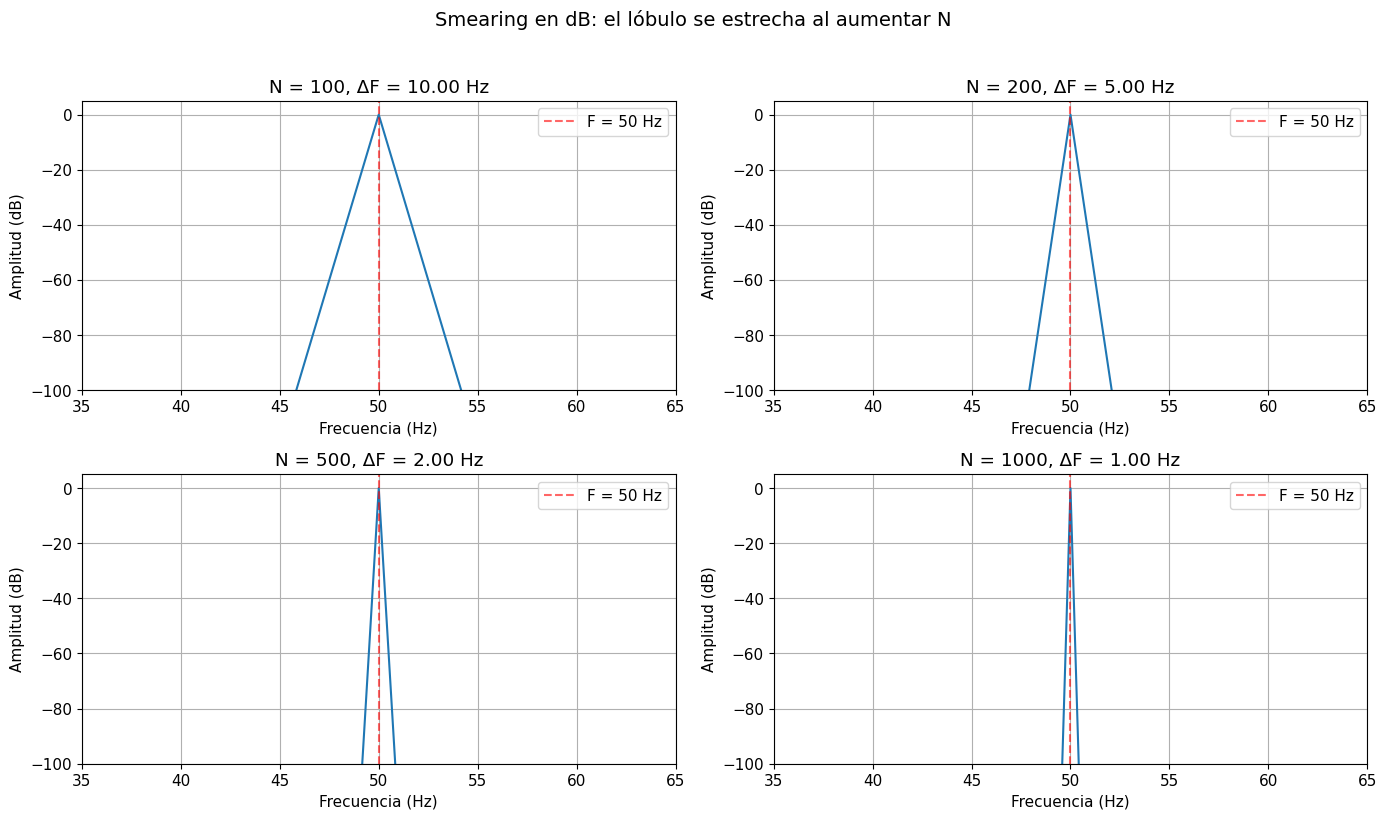

In [18]:
Fs4 = 1000
F4 = 50
A4 = 1.0
valores_N4 = [100, 200, 500, 1000]  # Que proporcionan valores de Delta F que consiguen que F4 sea un bin exacto

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, N4 in enumerate(valores_N4):
    n4 = np.arange(N4)
    t4 = n4 / Fs4
    DeltaF4 = Fs4 / N4

    x4 = A4 * np.sin(2 * np.pi * F4 * t4)

    X4 = np.fft.fft(x4)
    fr4 = np.fft.fftfreq(N4, d=1/Fs4)

    idx_pos = fr4 >= 0
    fr4_pos = fr4[idx_pos]
    A4_pos = np.abs(X4[idx_pos]) / N4
    if len(A4_pos) > 2:
        A4_pos[1:-1] *= 2

    A4_dB = 20 * np.log10(A4_pos + 1e-12)

    axes[i].plot(fr4_pos, A4_dB)
    axes[i].set_xlim([35, 65])
    axes[i].set_ylim([-100, 5])
    axes[i].axvline(x=F4, color='r', linestyle='--', alpha=0.6, label=f'F = {F4} Hz')
    axes[i].set_title(f'N = {N4}, ΔF = {DeltaF4:.2f} Hz')
    axes[i].set_xlabel('Frecuencia (Hz)')
    axes[i].set_ylabel('Amplitud (dB)')
    axes[i].legend()

plt.suptitle('Smearing en dB: el lóbulo se estrecha al aumentar N', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Bloque 4b · Convolución en frecuencia y origen del Smearing
Reutilizamos un caso sin leakage: frecuencia alineada con un bin + ventana rectangular

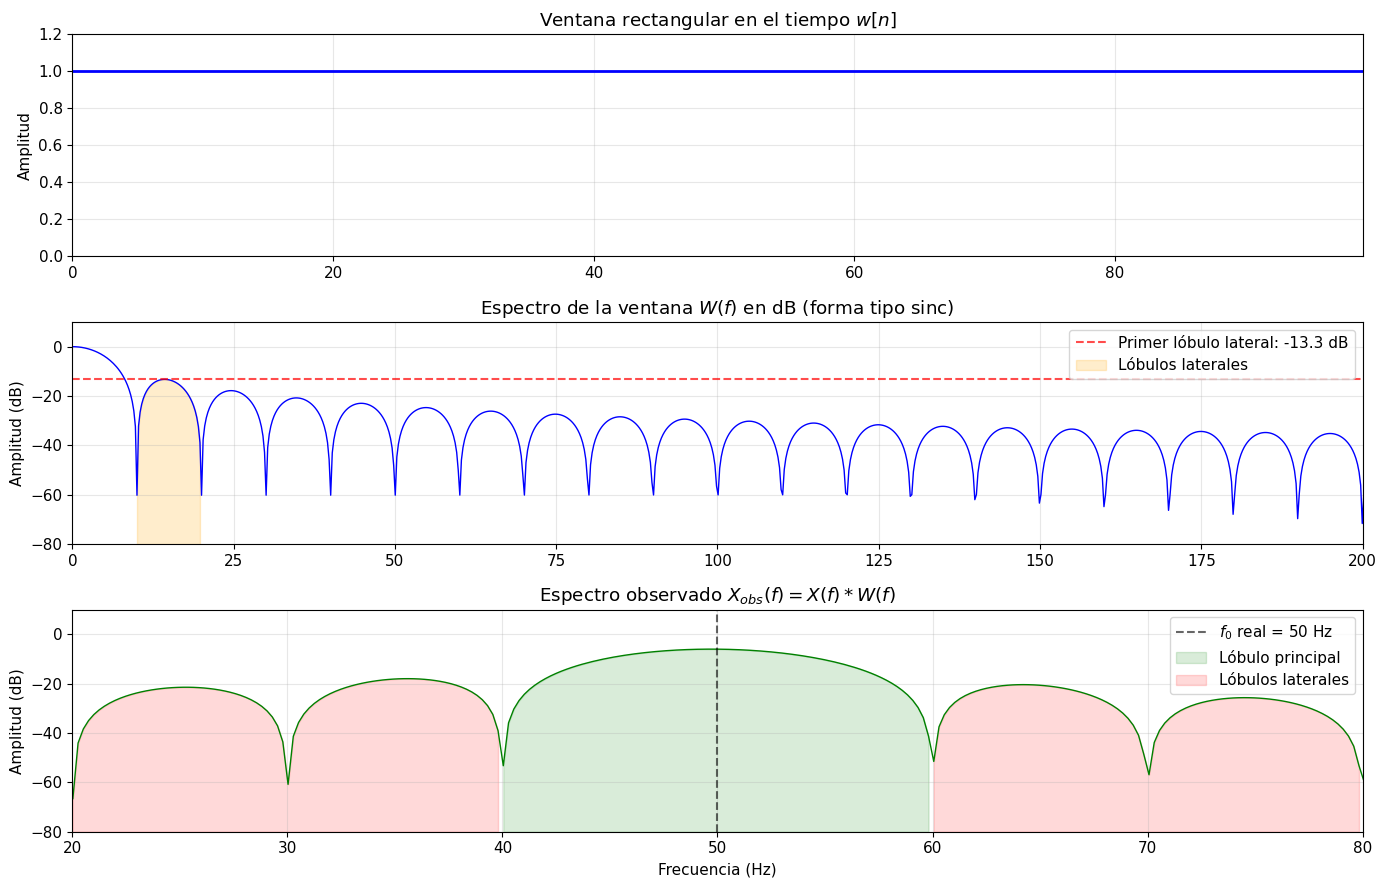

In [19]:
# Parámetros (caso sin leakage: frecuencia alineada con bin)
Fs4 = 1000
N4 = 100
T4 = N4 / Fs4   # Duración del segmento de señal
n4 = np.arange(N4)

F4 = 50       # Hz (bin exacto)
A4 = 1.0

# Señal
x4 = A4 * np.sin(2 * np.pi * F4 * n4 / Fs4)

# Ventana rectangular implícita
w4 = np.ones(N4)

# Señal observada
x4_obs = x4 * w4

# Zero-padding para mejor visualización
NFFT4 = 4096

# Espectro de la ventana
W4 = np.fft.rfft(w4, NFFT4)
fW4 = np.fft.rfftfreq(NFFT4, d=1/Fs4)
W4_dB = 20 * np.log10(np.abs(W4) / N4 + 1e-12)

# Espectro de la señal observada
X4_obs = np.fft.rfft(x4_obs, NFFT4)
fX4 = np.fft.rfftfreq(NFFT4, d=1/Fs4)
X4_obs_dB = 20 * np.log10(np.abs(X4_obs) / N4 + 1e-12)

# === VISUALIZACIÓN ===
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

# 1) Ventana en tiempo
axes[0].plot(n4, w4, 'b-', linewidth=2)
axes[0].set_xlim([0, N4 - 1])
axes[0].set_ylim([0, 1.2])
axes[0].set_title('Ventana rectangular en el tiempo $w[n]$')
axes[0].set_ylabel('Amplitud')
axes[0].grid(True, alpha=0.3)

# 2) Espectro de la ventana (sinc)
axes[1].plot(fW4, W4_dB, 'b-', linewidth=1)
axes[1].set_xlim([0, 200])
axes[1].set_ylim([-80, 10])
axes[1].axhline(y=-13.3, color='r', linestyle='--', alpha=0.7, label='Primer lóbulo lateral: -13.3 dB')

mask_sidelobe = (fW4 > 10) & (fW4 < 20)
axes[1].fill_between(
    fW4[mask_sidelobe],
    W4_dB[mask_sidelobe],
    -80,
    alpha=0.2,
    color='orange',
    label='Lóbulos laterales'
)

axes[1].set_title('Espectro de la ventana $W(f)$ en dB (forma tipo sinc)')
axes[1].set_ylabel('Amplitud (dB)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) Espectro observado (smearing)
axes[2].plot(fX4, X4_obs_dB, 'g-', linewidth=1)
axes[2].axvline(x=F4, color='k', linestyle='--', alpha=0.6, label=f'$f_0$ real = {F4} Hz')
axes[2].set_xlim([20, 80])
axes[2].set_ylim([-80, 10])

# Máscaras correctas (sin artefactos)
mask_main = (fX4 > F4 - 10) & (fX4 < F4 + 10)
mask_side_left = (fX4 > F4 - 30) & (fX4 < F4 - 10)
mask_side_right = (fX4 > F4 + 10) & (fX4 < F4 + 30)

# Lóbulo principal
axes[2].fill_between(
    fX4[mask_main],
    X4_obs_dB[mask_main],
    -80,
    alpha=0.15,
    color='green',
    label='Lóbulo principal'
)

# Lóbulos laterales (izquierda)
axes[2].fill_between(
    fX4[mask_side_left],
    X4_obs_dB[mask_side_left],
    -80,
    alpha=0.15,
    color='red',
    label='Lóbulos laterales'
)

# Lóbulos laterales (derecha)
axes[2].fill_between(
    fX4[mask_side_right],
    X4_obs_dB[mask_side_right],
    -80,
    alpha=0.15,
    color='red'
)

axes[2].set_title('Espectro observado $X_{obs}(f) = X(f) * W(f)$')
axes[2].set_xlabel('Frecuencia (Hz)')
axes[2].set_ylabel('Amplitud (dB)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# === VALIDACIÓN ===
print(f"Duración T = {T4:.3f} s")
print(f"Resolución Δf = {Fs4/N4:.1f} Hz")
print(f"Frecuencia F = {F4} Hz (bin exacto)")
print(f"Ancho aproximado del lóbulo principal: 2/T = {2/T4:.1f} Hz")
print("Primer lóbulo lateral: -13.3 dB")
print("\n✓ Smearing visualizado como convolución en frecuencia")

Duración T = 0.100 s
Resolución Δf = 10.0 Hz
Frecuencia F = 50 Hz (bin exacto)
Ancho aproximado del lóbulo principal: 2/T = 20.0 Hz
Primer lóbulo lateral: -13.3 dB

✓ Smearing visualizado como convolución en frecuencia


### Explicación (OBLIGATORIA)

1. **En el Bloque 3b vimos que una discontinuidad en los extremos introduce muchas frecuencias. En este bloque vemos que la ventana rectangular tiene un espectro tipo sinc. ¿Cómo se relacionan ambas ideas?**
(Pista: piensa que la discontinuidad es consecuencia de la ventana rectangular en el tiempo.)

*Tu respuesta:*

```
La discontinuidad en el tiempo no es un problema aparte, sino una consecuencia directa de la ventana rectangular.
Cuando recortas la señal con una ventana rectangular:
. En el tiempo: cortas bruscamente la señal
. Eso crea bordes no naturales
Esos bordes equivalen a multiplicar por una ventana rectangular. Y multiplicar en el tiempo -> convolucionar en frecuencia.
La señal ideal se difumina al convolucionarla con la sinc de la ventana. Y el resultado es la discontinuidad en tiempo.
```

**2. Lóbulos laterales y detección de señales: En el gráfico anterior, los lóbulos laterales de la función sinc están a -13.3 dB.
Si existiera un tono débil a 60 Hz (cerca de \(f_0 = 50\) Hz), ¿podría quedar enmascarado por estos lóbulos laterales?  
Explica por qué.**

*Tu respuesta:*

```
Sí.
El lóbulo lateral de la sinc está a -13.3 dB, eso significa que contamina frecuencias vecinas con energía relativamente alta.
El lóbulo lateral del 50 Hz puede ser más fuerte que el tono de 60 Hz, el tono débil queda oculto dentro del ruido estructural del espectro.
```

**3. Otras ventanas: Si en lugar de una ventana rectangular utilizáramos otro tipo de ventana ¿como serían sus lóbulos principal y secundarios ideales?**

*Tu respuesta:*

```
Las ventanas ideales buscan el siguiente compromiso:
. Lóbulo principal: debe ser lo más estrecho posible -> buena resolución en frecuencia.
. Lóbulos secundarios: deben ser lo más bajos posible -> mejor leakage y mejor detección de señales débiles.
```



---
### Bloque 4c · Otros tipos de ventanas: reducir el leakage

#### Contexto teórico

Aplicar una **ventana** a la señal antes de la FFT suaviza los extremos, reduciendo la discontinuidad y por tanto el leakage.

**Ventanas comunes:**

| Ventana | Lóbulo principal | Lóbulos laterales | Uso típico |
|---------|-----------------|-------------------|------------|
| Rectangular (ninguna) | Estrecho (mejor resolución) | Altos (-13 dB) | Frecuencias bien separadas |
| Hann | Más ancho | Bajos (-31 dB) | Propósito general |
| Hamming | Similar a Hann | Aún más bajos (-43 dB) | Análisis de voz |
| Blackman | Muy ancho | Muy bajos (-58 dB) | Detectar tonos débiles |

**Trade-off fundamental:** Reducir lóbulos laterales → ensancha el lóbulo principal → peor resolución.

**Ganancia coherente:** Las ventanas atenúan la señal en promedio. Hay que compensar dividiendo por el factor de ganancia.

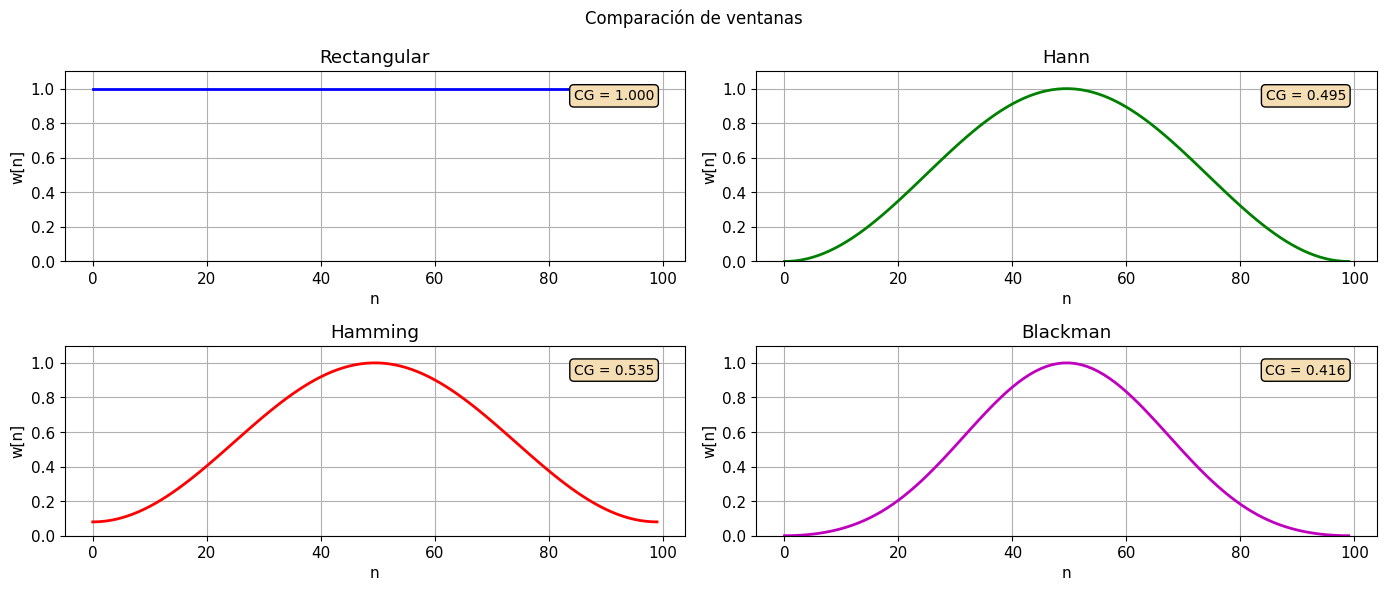

In [21]:
# === IMPLEMENTACIÓN: Ventanas en dominio temporal ===
# Genera y visualiza las ventanas rectangular, Hann, Hamming y Blackman.
# Aplica cada ventana a una señal sinusoidal y observa el efecto.

N = 100

# Crear ventanas
w_rect = np.ones(N)
w_hann = np.hanning(N)
w_hamming = np.hamming(N)
w_blackman = np.blackman(N)

# Visualizar las ventanas
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
ventanas = [('Rectangular', w_rect, 'b'), 
            ('Hann', w_hann, 'g'),
            ('Hamming', w_hamming, 'r'), 
            ('Blackman', w_blackman, 'm')]

for ax, (nombre, w, color) in zip(axes.flat, ventanas):
    ax.plot(w, color=color, linewidth=2)
    ax.set_title(f'{nombre}')
    ax.set_ylim([0, 1.1])
    ax.set_xlabel('n')
    ax.set_ylabel('w[n]')
    
    # Mostrar ganancia coherente
    cg = np.mean(w)
    ax.text(0.95, 0.85, f'CG = {cg:.3f}', transform=ax.transAxes, 
            ha='right', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

plt.suptitle('Comparación de ventanas', fontsize=12)
plt.tight_layout()
plt.show()



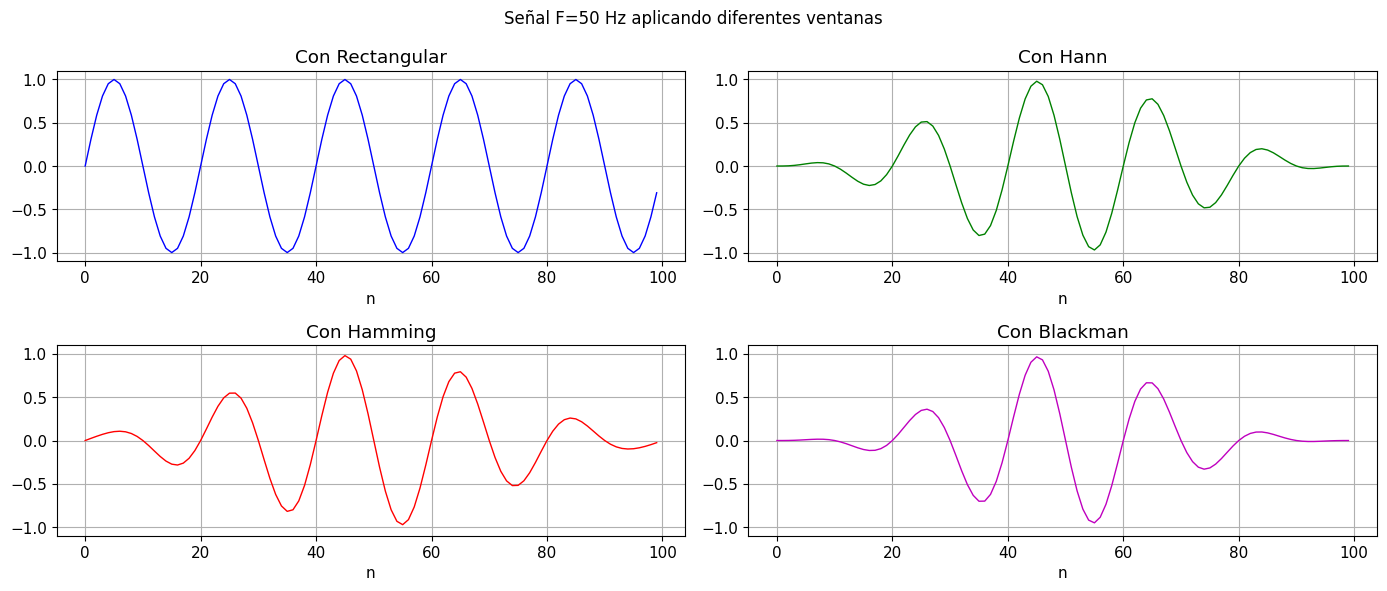

Observa cómo las ventanas 'suavizan' los extremos de la señal
→ Esto reduce la discontinuidad cuando la DFT asume periodicidad


In [22]:
# === Efecto de aplicar ventana a una señal ===
F0 = 50  # Alineada con bins (Δf = 10 Hz), por lo que no hay leakage
Fs = 1000
n = np.arange(N)
x = np.sin(2*np.pi*F0*n/Fs)

# Aplicar ventanas
x_rect = x * w_rect
x_hann = x * w_hann
x_hamming = x * w_hamming
x_blackman = x * w_blackman

# Visualizar señales ventaneadas
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
señales = [('Con Rectangular', x_rect, 'b'), 
           ('Con Hann', x_hann, 'g'),
           ('Con Hamming', x_hamming, 'r'), 
           ('Con Blackman', x_blackman, 'm')]

for ax, (nombre, s, color) in zip(axes.flat, señales):
    ax.plot(s, color=color, linewidth=1)
    ax.set_title(f'{nombre}')
    ax.set_ylim([-1.1, 1.1])
    ax.set_xlabel('n')

plt.suptitle(f'Señal F={F0} Hz aplicando diferentes ventanas', fontsize=12)
plt.tight_layout()
plt.show()

print("Observa cómo las ventanas 'suavizan' los extremos de la señal")
print("→ Esto reduce la discontinuidad cuando la DFT asume periodicidad")

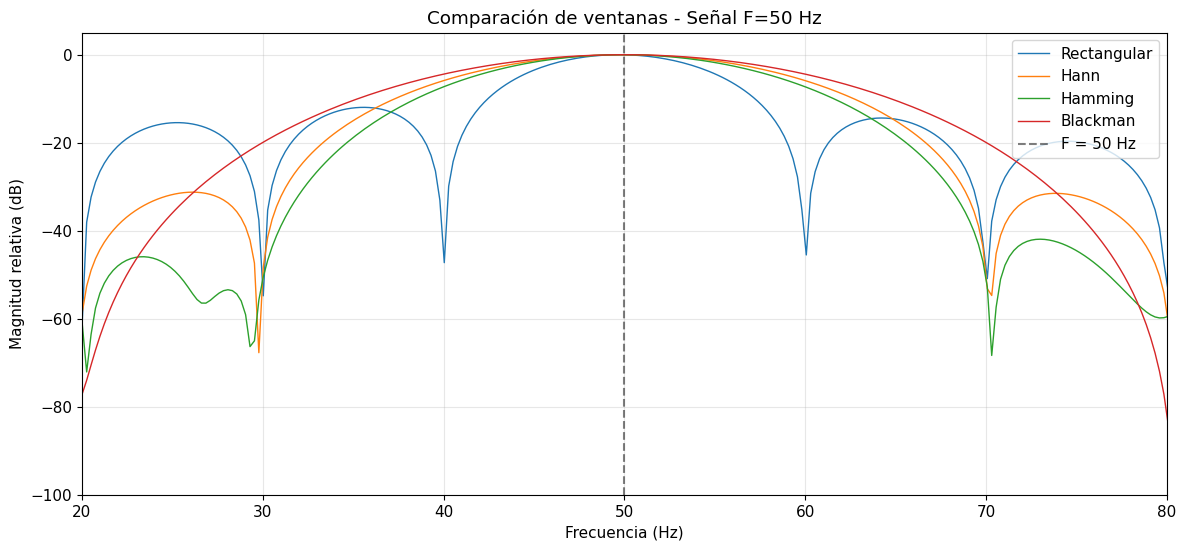

In [23]:
# === IMPLEMENTACIÓN: Comparación de espectros ===
# Calcula el espectro con cada ventana (compensando ganancia coherente).
# Compara en escala dB para ver los lóbulos laterales.

def espectro_dB(x, Fs, window, NFFT=4096):
    """Calcula espectro en dB compensando ganancia coherente y con zero-padding."""
    N = len(x)
    x_windowed = x * window
    cg = np.mean(window)  # Ganancia coherente
    
    Xr = np.fft.rfft(x_windowed, NFFT)
    fr = np.fft.rfftfreq(NFFT, d=1/Fs)
    
    # Normalización + compensación de ganancia coherente
    A = np.abs(Xr) / (N * cg)
    
    # Normalizar al máximo para comparar forma espectral
    A = A / np.max(A)
    
    # dB
    A_dB = 20 * np.log10(A + 1e-12)
    return fr, A_dB

# Calcular espectros
fr, A_rect_dB = espectro_dB(x, Fs, w_rect)
_, A_hann_dB = espectro_dB(x, Fs, w_hann)
_, A_hamming_dB = espectro_dB(x, Fs, w_hamming)
_, A_blackman_dB = espectro_dB(x, Fs, w_blackman)

# Visualización comparativa
plt.figure(figsize=(14, 6))
plt.plot(fr, A_rect_dB, linewidth=1, label='Rectangular')
plt.plot(fr, A_hann_dB, linewidth=1, label='Hann')
plt.plot(fr, A_hamming_dB, linewidth=1, label='Hamming')
plt.plot(fr, A_blackman_dB, linewidth=1, label='Blackman')

plt.axvline(x=F0, color='k', linestyle='--', alpha=0.5, label=f'F = {F0} Hz')
plt.xlim([20, 80])
plt.ylim([-100, 5])
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud relativa (dB)')
plt.title(f'Comparación de ventanas - Señal F={F0} Hz')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

### Explicación (OBLIGATORIA)

1. Observa los lóbulos laterales en la gráfica. ¿Cuál ventana los tiene más bajos?

   *Tu respuesta:*

```
La ventana que tiene los lóbulos laterales más bajos es la Blackman.
Esto ocurre porque está diseñada precisamente para reducir al máximo la energía que se escapa fuera del lóbulo principal. En el dominio de la frecuencia eso se traduce en que los sidelobes están muy atenuados, bastante más que en el resto de ventanas típicas.
```

2. ¿Qué le pasa al ancho del lóbulo principal al usar Blackman vs Rectangular?

*Tu respuesta:*

```
Cuando pasas de una ventana rectangular a una Blackman, el lóbulo principal se vuelve claramente más ancho.
Con la rectangular tienes un pico mñas estrecho, lo que significa que puedes distinguir mejor frecuencias cercanas entre sí. En cambio, la Blackman ensancha ese pico, lo que hace que dos frecuencias próximas sean más difíciles de separar.
```

3. ¿Por qué hay que compensar la ganancia coherente?

*Tu respuesta:*

```
Porque la ventana reduce la amplitud media de la señal, si no se corrige eso, el espectro sale más bajo de lo real. Se divide por la media de la ventana para recuperar la escala.
```

4. Explica el trade-off: ¿cuándo elegirías Rectangular vs Blackman?

*Tu respuesta:*

```
Rectangular: mejor resolución, más leakage -> cuando las frecuencias están separadas.
Blackman: menos leakage, peor resolución -> cuando hay tonos débiles cerca de fuertes.
```

#### Propiedades espectrales de ventanas comunes

La siguiente tabla resume las propiedades espectrales de las ventanas más usadas:

| No. | Ventana | Ancho lóbulo principal | Rolloff rate | Pico lóbulo lateral (dB) |
|:---:|---------|:--------------------:|:-----:|:------------------------:|
| 1 | **Rectangular** | $4\pi/T$ | -6 | **-13.3** |
| 2 | **Bartlett (triangular)** | $8\pi/T$ | -12 | -26.5 |
| 3 | **Hanning (Hann)** | $8\pi/T$ | -18 | -31.5 |
| 4 | **Hamming** | $8\pi/T$ | -6 | -42.7 |
| 5 | **Blackman** | $12\pi/T$ | -18 | -58.1 |
| 6 | **Kaiser** ($\alpha=8.168$) | $11.2\pi/T$ | -6 | -59.9 |

#### Interpretación de la tabla

**Ancho del lóbulo principal:**
- Determina la **resolución en frecuencia** (capacidad de separar tonos cercanos)
- Rectangular tiene el lóbulo más estrecho (mejor resolución) pero sidelobes muy altos
- Blackman tiene un lóbulo muy ancho (peor resolución) pero sidelobes bajísimos

**Rolloff rate (tasa de caída):**
- Cómo decae la amplitud de los sidelobes alejándose del lóbulo principal
- Mayor rolloff → sidelobes decaen más rápidamente → menos leakage a distancia
- Ejemplo: Hann (-18 dB/oct) decae 3 veces más rápido que rectangular (-6 dB/oct)

**Pico del lóbulo lateral:**
- Amplitud del sidelobe más alto respecto al lóbulo principal
- Rectangular: -13.3 dB (muy alto)
- Blackman: -58.1 dB (excelente para tonos débiles)

#### El trade-off fundamental

No existe una ventana "perfecta". La elección depende del problema:

- **Rectangular:** Mejor resolución, peores sidelobes → úsala cuando los tonos están bien separados
- **Hann/Hamming:** Buen balance → propósito general, análisis de voz
- **Blackman:** Excelentes sidelobes → detectar tonos débiles, pero sacrifica resolución

#### Scalloping Loss

**Problema:** Cuando usamos una ventana, la máxima amplitud que podemos medir puede ser menor que la verdadera, incluso en el pico del espectro.

**Razón:** Si la verdadera frecuencia cae exactamente **entre dos bins** (en el "valle" de interpolación), el pico observado es más bajo que el valor real.

**Ejemplo:** Con ventana rectangular, el "scalloping loss" es de **3.92 dB** cuando la frecuencia cae exactamente a mitad de camino entre bins.

Este es uno de los motivos por los que en aplicaciones de medida de amplitud (ej. analizadores de espectro de audio), se usan ventanas como Hann: el scalloping loss es menor (-1.5 dB).

**Conclusión:** Además de leakage, la ventana afecta también a la precisión de **amplitud** de las medidas.


### Explicación (OBLIGATORIA): Scalloping Loss

1. **¿Qué es el scalloping loss?** Explica por qué la amplitud medida puede ser menor que la verdadera cuando la frecuencia cae entre dos bins.

   *Tu respuesta:* El scalloping loss es la pérdida de amplitud medida que ocurre cuando la frecuencia de una señal no coincide exactamente con un bin de la DFT.
   Cuando la frecuencia cae entre dos bins, el valor máximo del espectro no coincide con el valor real de la señal, sino que aparece reducido.
   Esto sucede porque la DFT solo evalúa puntos discretos en frecuencia, y el máximo real puede quedar entre esos puntos. Como consecuencia, la amplitud medida es menor que la verdadera.

2. **Impacto en medidas:** Si necesitas medir amplitudes de tonos con precisión (ej. en un analizador de espectro), ¿qué ventana elegirías y por qué?

   *Tu respuesta:* Si necesitas medir amplitudes con precisión elegiría una ventana tipo Hann.
   Porque tiene menor scalloping loss (-1.5 dB frente a -3.92 dB de la rectangular) y reduce el error en la estimación de amplitud.
   Como resultado, mediciones más fiables.

3. **Conexión con leakage:** ¿Hay alguna relación entre el ancho del lóbulo principal y el scalloping loss?

   *Tu respuesta:* Sí, el scalloping loss depende del ancho del lóbulo principal de la ventana:
   . Lóbulo principal estrecho (rectangular) -> mayor resolución pero mayor scalloping loss.
   . Lóbulo principal ancho (Hann, Hamming) -> menor scalloping loss pero peor resolución en frecuencia.

---

## Preguntas de control

Responde cada pregunta en 2–6 líneas:

### P1. ¿Qué determina la resolución real en frecuencia y cómo se puede mejorar?

*Tu respuesta:* La resolución en frecuencia viene determinada por DeltaF = Fs / N, es decir, depende del número de muestras observadas.
Cuanto mayor es N, menor es DeltaF y mejor se pueden distinguir frecuencias cercanas. Se mejora aumentando la duración de la señal, no con zero-padding.

### P2. ¿Qué aporta el zero-padding y qué NO aporta? Da un ejemplo de uso útil.

*Tu respuesta:* El zero-padding aumenta el número de puntos en la FFT, haciendo el espectro más suave y permitiendo localizar mejor los picos.
Sin embargo, no mejira la resolución real en frecuencia ni añade información nueva.

### P3. Explica por qué ocurre el leakage usando el concepto de "discontinuidad periódica".

*Tu respuesta:* El leakage ocurre porque la DFT asume que la señal es periódica.
Si la señal no contiene un número entero de ciclos, al repetirse aparece una discontinuidad en los extremos. Esa discontinuidad introduce muchas frecuencias, haciendo que la energía se reparta entre varios bins.

### P4. ¿Por qué una ventana Hann reduce los lóbulos laterales pero empeora la resolución frente a la rectangular?

*Tu respuesta:* La ventana Hann reduce los lóbulos laterales porque suaviza los borde de la señal, evitando discontinuidades bruscas.
Sin embargo, esto ensancha el lóbulo principal, empeorando la resolución en frecuencia. Es un compromiso entre menor leakage y menor capacidad de separar frecuencias cercanas.



---

## Checklist final

- [ ] Comparativa duración corta vs larga (resolución)
- [ ] Zero-padding (N, 4N, 16N) interpretado correctamente
- [ ] Discontinuidad periódica visualizada
- [ ] Leakage observado y verificación de Parseval
- [ ] Leakage explicado via propiedad de convolución (Bloque 3c)
- [ ] Tabla de propiedades de ventanas revisada y scalloping loss comprendido (Bloque 4c)
- [ ] Ventanas comparadas (rectangular, Hann, Hamming, Blackman)

---

## (Opcional) Extensiones

1. **Ventana Kaiser:** Investiga la ventana Kaiser que permite ajustar el trade-off con un parámetro β. Compárala con Hann.

2. **Señal real de audio:** Carga un archivo de audio corto y analiza cómo cambia el espectro con diferentes ventanas.

3. **Scalloping loss:** Investiga qué es el "scalloping loss" y cómo afecta a la medida de amplitud cuando hay leakage.